In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.dfCleaning import Cleaning

----------
# Data Analysis
----------

### Loading the Movie Dataset

In [10]:
df = pd.read_csv('../data/movies.csv')
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3969,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3970,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3971,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3972,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


### Exploring Dataset Information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3974 entries, 0 to 3973
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Movie                                3974 non-null   str    
 1   Director                             3974 non-null   str    
 2   Running time                         3974 non-null   int64  
 3   Actor 1                              3974 non-null   str    
 4   Actor 2                              3974 non-null   str    
 5   Actor 3                              3972 non-null   str    
 6   Genre                                3974 non-null   str    
 7   Budget                               3974 non-null   int64  
 8   Box Office                           3974 non-null   int64  
 9   Actors Box Office %                  3974 non-null   float64
 10  Director Box Office %                3974 non-null   float64
 11  Earnings                             3974

In [12]:
df.describe()

,Running time,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
count,3974.000000,3.974000e+03,3.974000e+03,3.974000e+03,3974.000000,3.974000e+03,3974.000000,3971.000000,3974.000000,3974.000000
mean,109.967036,3.690639e+07,1.086770e+08,2.984678e+09,52.780695,7.177060e+07,1.106694,0.321330,2002.043785,6.467866
std,22.507658,4.270431e+07,1.798354e+08,1.344684e+11,35.360199,1.526573e+08,2.724019,1.209324,12.127027,1.072514
min,20.000000,1.100000e+03,5.000000e+04,0.000000e+00,0.000000,-3.231000e+08,0.000000,0.000000,1929.000000,1.600000
25%,95.000000,9.000000e+06,1.200000e+07,3.333000e+01,25.000000,0.000000e+00,0.000000,0.000000,1998.000000,5.900000
50%,106.000000,2.200000e+07,4.300000e+07,5.714000e+01,50.000000,1.850000e+07,0.000000,0.000000,2005.000000,6.600000
75%,120.000000,5.000000e+07,1.250000e+08,8.333000e+01,80.000000,8.100000e+07,1.000000,0.000000,2010.000000,7.200000
max,330.000000,3.900000e+08,2.923000e+09,6.805556e+12,100.000000,2.686000e+09,22.000000,13.000000,2016.000000,9.300000


### Missing Values Analysis and Duplicate Records Detection

In [13]:
df.isna().sum()

Movie                                  0
Director                               0
Running time                           0
Actor 1                                0
Actor 2                                0
Actor 3                                2
Genre                                  0
Budget                                 0
Box Office                             0
Actors Box Office %                    0
Director Box Office %                  0
Earnings                               0
Oscar and Golden Globes nominations    0
Oscar and Golden Globes awards         3
Release year                           0
IMDb score                             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(24)

In [15]:
df[df.duplicated(keep=False)].sort_values('Movie', ascending=True)

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
2146,Bad Moms,Jon Lucas,100,Mila Kunis,Jay Hernandez,Jada Pinkett Smith,Comedy,20000000,183000000,72.22,100.00,163000000,0,0.0,2016,6.7
2145,Bad Moms,Jon Lucas,100,Mila Kunis,Jay Hernandez,Jada Pinkett Smith,Comedy,20000000,183000000,72.22,100.00,163000000,0,0.0,2016,6.7
177,Carrie,Kimberly Peirce,100,Chloë Grace Moretz,Judy Greer,Portia Doubleday,Drama,30000000,84000000,77.00,50.00,54000000,0,0.0,2013,5.9
2269,Carrie,Kimberly Peirce,100,Chloë Grace Moretz,Judy Greer,Portia Doubleday,Drama,30000000,84000000,77.00,50.00,54000000,0,0.0,2013,5.9
2344,Crossroads,Tamra Davis,93,Britney Spears,Katherine Boecher,Dave Allen,Comedy,12000000,61000000,100.00,100.00,49000000,0,0.0,2002,3.3
2343,Crossroads,Tamra Davis,93,Britney Spears,Katherine Boecher,Dave Allen,Comedy,12000000,61000000,100.00,100.00,49000000,0,0.0,2002,3.3
265,Disturbia,D.J. Caruso,105,Sarah Roemer,Aaron Yoo,Jose Pablo Cantillo,Drama,20000000,118000000,88.89,80.00,98000000,0,0.0,2007,6.9
2403,Disturbia,D.J. Caruso,105,Sarah Roemer,Aaron Yoo,Jose Pablo Cantillo,Drama,20000000,118000000,88.89,80.00,98000000,0,0.0,2007,6.9
288,Dredd,Pete Travis,95,Wood Harris,Jason Cope,Rakie Ayola,Sci-Fi,35000000,41000000,33.33,0.00,6000000,0,0.0,2012,7.1
289,Dredd,Pete Travis,95,Wood Harris,Jason Cope,Rakie Ayola,Sci-Fi,35000000,41000000,33.33,0.00,6000000,0,0.0,2012,7.1


### Handling Missing Values and Duplicates

In [16]:
df = Cleaning(df)

In [17]:
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3898,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3899,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3900,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


---------
# Data Visualization
---------

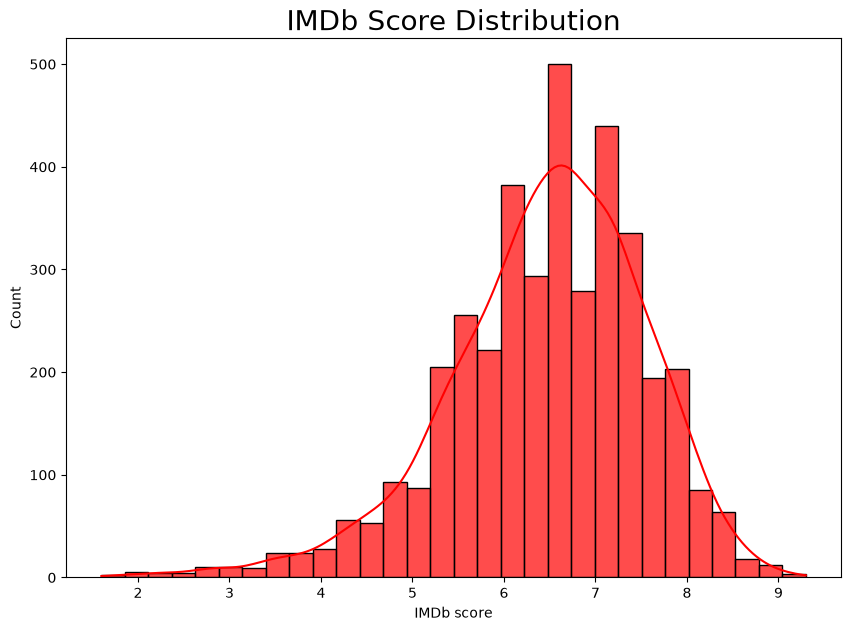

In [18]:
plt.figure(figsize = (10,7))
sns.histplot(df['IMDb score'], bins=30, color='red', alpha=0.7, kde=True)
plt.title('IMDb Score Distribution', fontsize=20)
plt.show()

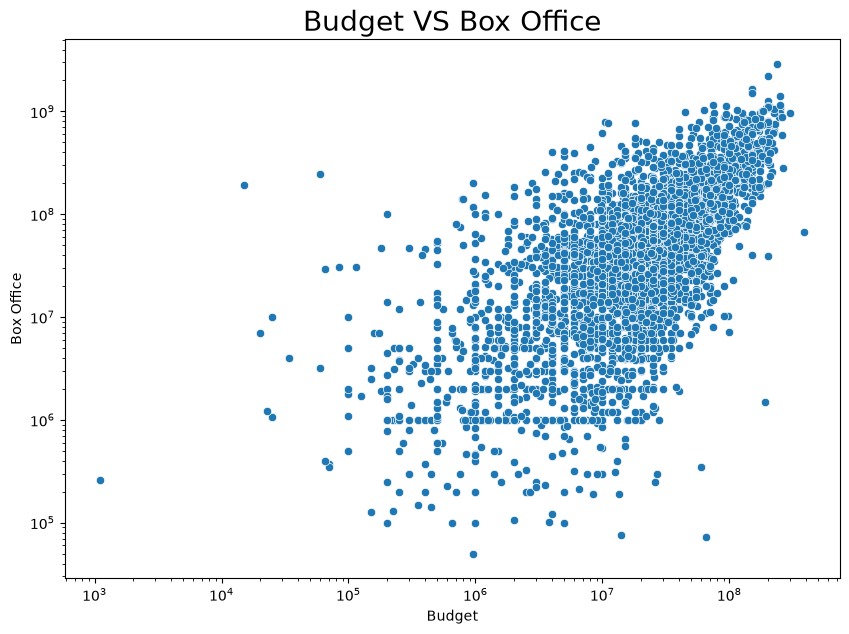

In [19]:
plt.figure(figsize = (10,7))
sns.scatterplot(df, x='Budget', y='Box Office')
plt.xscale('log')
plt.yscale('log')
plt.title('Budget VS Box Office', fontsize=20)
plt.show()

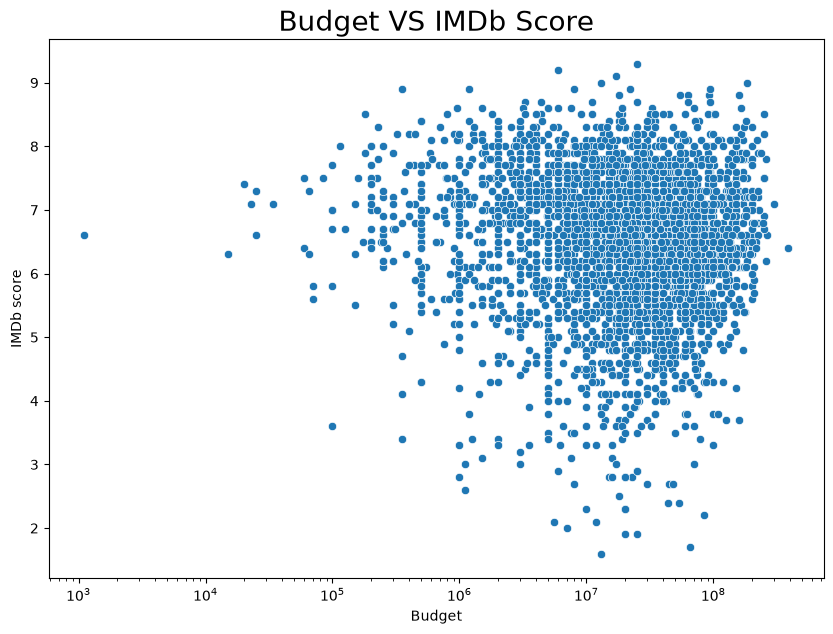

In [20]:
plt.figure(figsize = (10,7))
sns.scatterplot(df, x='Budget', y='IMDb score')
plt.xscale('log')
plt.title('Budget VS IMDb Score', fontsize=20)
plt.show()

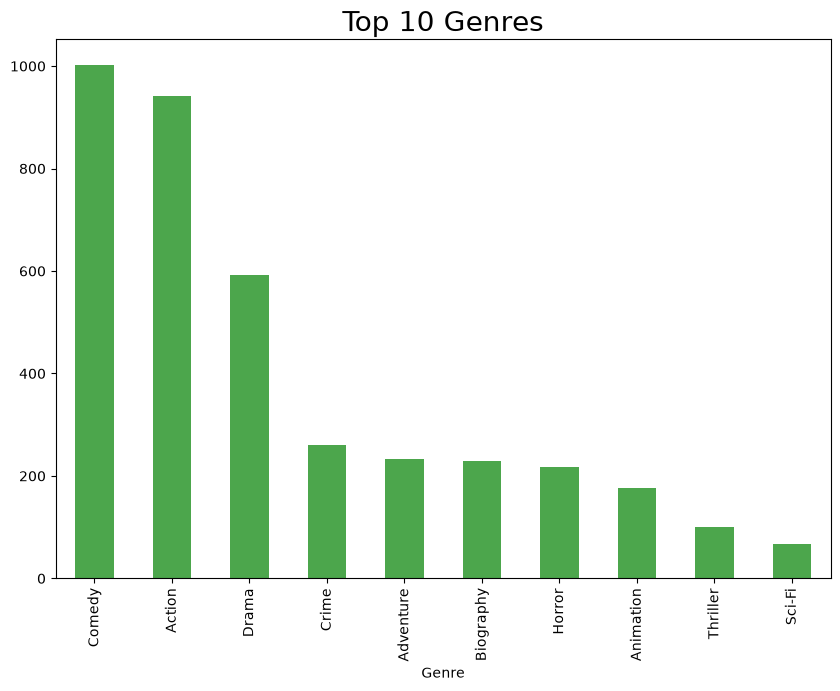

In [21]:
plt.figure(figsize = (10,7))
df['Genre'].value_counts().head(10).plot(kind='bar', color='green', alpha=0.7)
plt.title('Top 10 Genres', fontsize=20)
plt.show()

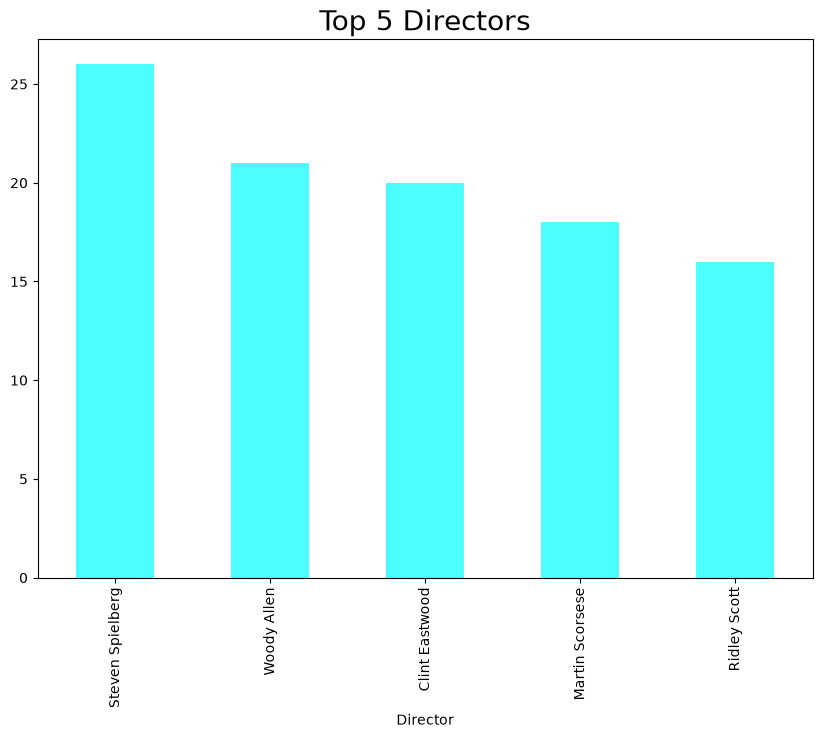

In [22]:
plt.figure(figsize = (10,7))
df['Director'].value_counts().head(5).plot(kind='bar', color='cyan', alpha=0.7)
plt.title('Top 5 Directors', fontsize=20)
plt.show()

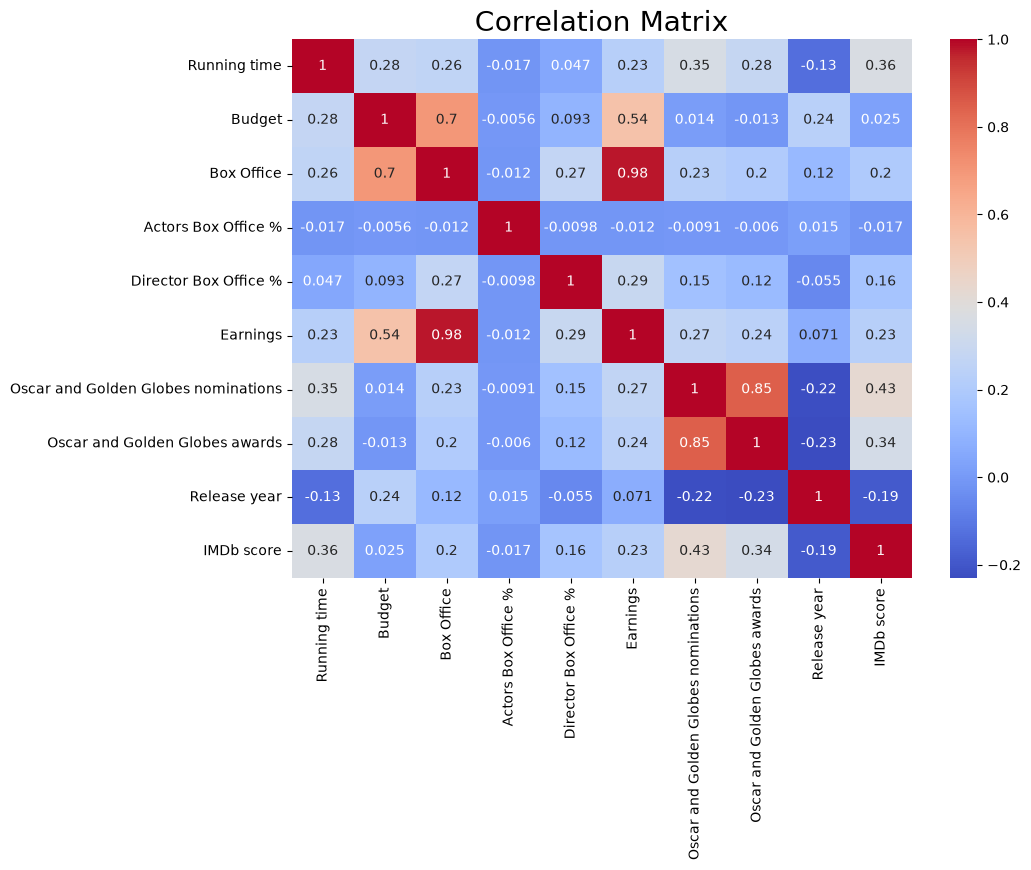

In [23]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix', fontsize=20)
plt.show()